In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100})
 
print('Libraries loaded successfully!')


Libraries loaded successfully!


In [2]:
# 1: DATA CLEANING 
 
df = pd.read_csv('online_retail.csv', encoding='ISO-8859-1')
print(f'Raw shape: {df.shape}')
 
# Parse dates
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
 
# Remove cancelled orders (InvoiceNo starts with 'C')
cancelled = df['InvoiceNo'].astype(str).str.startswith('C')
print(f'Cancelled orders removed: {cancelled.sum():,}')
df = df[~cancelled].copy()
 
# Drop rows with missing CustomerID
missing = df['CustomerID'].isna().sum()
print(f'Missing CustomerID removed: {missing:,}')
df = df.dropna(subset=['CustomerID'])
 
# Remove invalid Quantity or Price
invalid = (df['Quantity'] <= 0) | (df['UnitPrice'] <= 0)
print(f'Invalid rows removed: {invalid.sum():,}')
df = df[~invalid].copy()
 
# Add Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['CustomerID'] = df['CustomerID'].astype(int)
 
print(f'\nClean shape: {df.shape}')
print(f'Date range: {df.InvoiceDate.min().date()}  to  {df.InvoiceDate.max().date()}')
print(f'Unique customers: {df.CustomerID.nunique():,}')
print(f'Total revenue:   £{df.Revenue.sum():,.2f}')
 
df.head()


Raw shape: (541909, 8)
Cancelled orders removed: 9,288
Missing CustomerID removed: 134,697
Invalid rows removed: 40

Clean shape: (397884, 9)
Date range: 2010-12-01  to  2011-12-09
Unique customers: 4,338
Total revenue:   £8,911,407.90


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


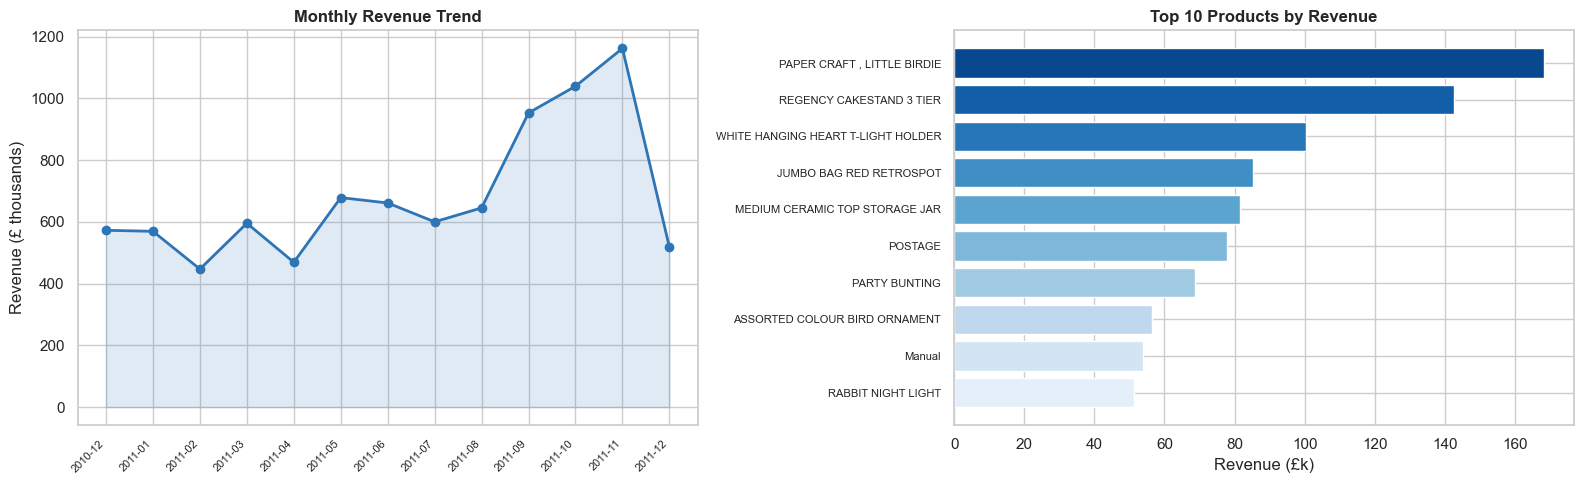

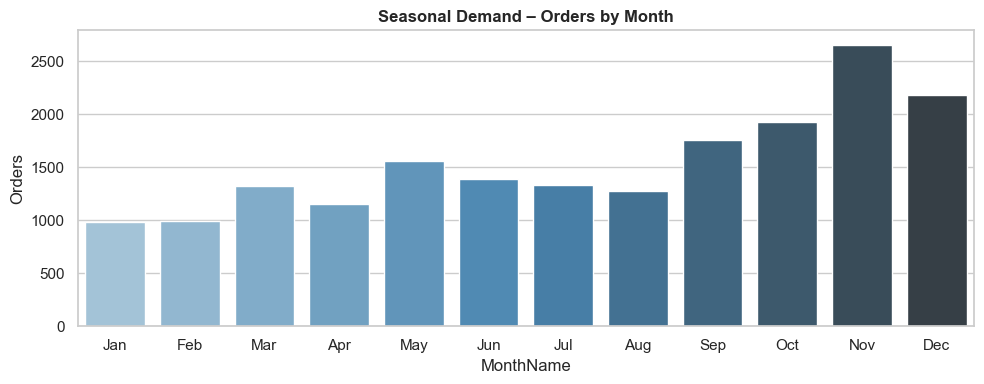

Step 2 complete. Charts saved.


In [3]:
#  2: EDA
 
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_rev = df.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_rev['YearMonth'] = monthly_rev['YearMonth'].astype(str)
 
top_products = (df.groupby('Description')['Revenue']
    .sum().sort_values(ascending=False).head(10).reset_index())
 
df['Month'] = df['InvoiceDate'].dt.month
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
seasonal = df.groupby('Month')['InvoiceNo'].nunique().reset_index()
seasonal.columns = ['Month','Orders']
seasonal['MonthName'] = seasonal['Month'].map(month_names)
 
# Plot: Monthly Revenue Trend
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
ax.plot(monthly_rev['YearMonth'], monthly_rev['Revenue']/1000,
        marker='o', linewidth=2, color='#2E75B6')
ax.fill_between(range(len(monthly_rev)), monthly_rev['Revenue']/1000,
                alpha=0.15, color='#2E75B6')
ax.set_xticks(range(len(monthly_rev)))
ax.set_xticklabels(monthly_rev['YearMonth'], rotation=45, ha='right', fontsize=8)
ax.set_title('Monthly Revenue Trend', fontweight='bold')
ax.set_ylabel('Revenue (£ thousands)')
 
# Plot: Top 10 Products
ax2 = axes[1]
colors = sns.color_palette('Blues_r', len(top_products))
ax2.barh(top_products['Description'], top_products['Revenue']/1000, color=colors)
ax2.invert_yaxis()
ax2.set_title('Top 10 Products by Revenue', fontweight='bold')
ax2.set_xlabel('Revenue (£k)')
ax2.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('eda_charts.png', bbox_inches='tight')
plt.show()
 
# Plot: Seasonal Demand
fig2, ax3 = plt.subplots(figsize=(10, 4))
sns.barplot(data=seasonal, x='MonthName', y='Orders', palette='Blues_d', ax=ax3)
ax3.set_title('Seasonal Demand – Orders by Month', fontweight='bold')
plt.tight_layout()
plt.savefig('seasonal_demand.png', bbox_inches='tight')
plt.show()
print('Step 2 complete. Charts saved.')


Total customers: 4,338
Avg CLV: £2,054.27
Median CLV: £674.49
Top 26.1% of customers = 80% of revenue


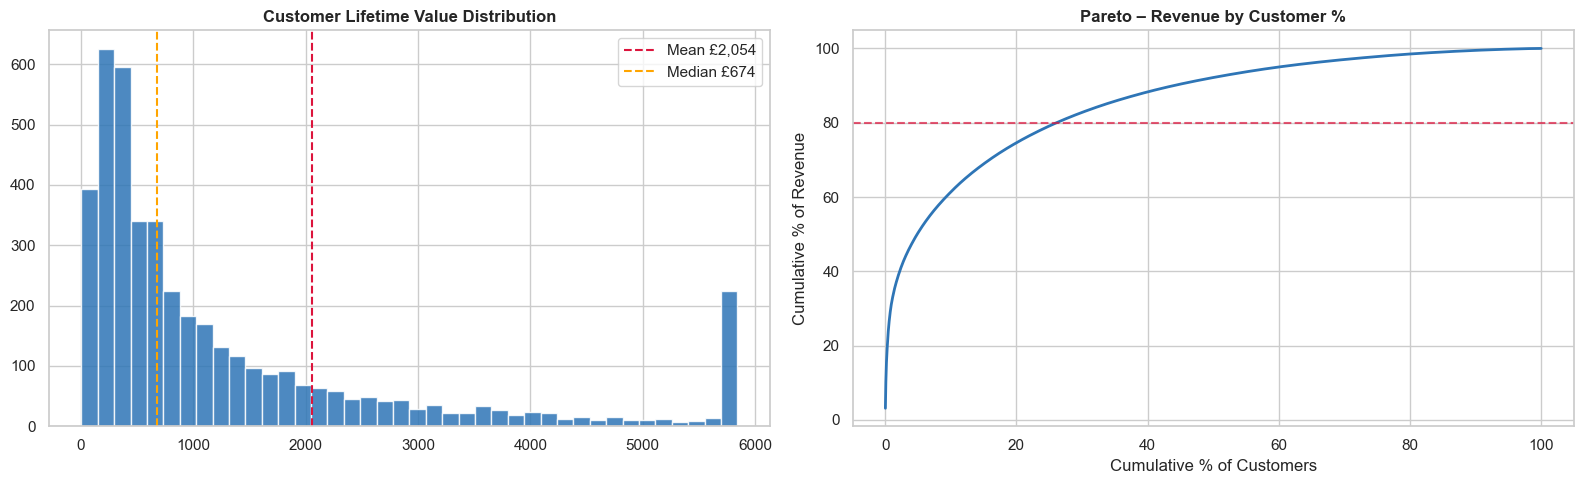

BA GENERATED


In [4]:
#   3: BA 
 
# Customer Lifetime Value
clv = (df.groupby('CustomerID')
    .agg(
        TotalRevenue=('Revenue','sum'),
        TotalOrders=('InvoiceNo','nunique'),
        TotalItems=('Quantity','sum'),
        FirstPurchase=('InvoiceDate','min'),
        LastPurchase=('InvoiceDate','max'),
    ).reset_index())
clv['AvgOrderValue'] = clv['TotalRevenue'] / clv['TotalOrders']
clv['LifespanDays'] = (clv['LastPurchase'] - clv['FirstPurchase']).dt.days
clv = clv.sort_values('TotalRevenue', ascending=False)
 
print(f'Total customers: {len(clv):,}')
print(f'Avg CLV: £{clv.TotalRevenue.mean():,.2f}')
print(f'Median CLV: £{clv.TotalRevenue.median():,.2f}')
 
# Pareto Analysis
clv_s = clv.sort_values('TotalRevenue', ascending=False).reset_index(drop=True)
clv_s['CumRev'] = clv_s['TotalRevenue'].cumsum()
clv_s['CumPct'] = clv_s['CumRev'] / clv_s['TotalRevenue'].sum() * 100
clv_s['CustPct'] = (clv_s.index+1) / len(clv_s) * 100
top80 = clv_s[clv_s['CumPct'] <= 80]
print(f'Top {len(top80)/len(clv_s)*100:.1f}% of customers = 80% of revenue')
 
# Country Revenue
country_rev = (df.groupby('Country')['Revenue']
    .sum().sort_values(ascending=False).head(10).reset_index())
 
# Plot: CLV Distribution + Pareto Curve
fig, axes = plt.subplots(1, 2, figsize=(16,5))
clv_cap = clv['TotalRevenue'].clip(upper=clv['TotalRevenue'].quantile(0.95))
axes[0].hist(clv_cap, bins=40, color='#2E75B6', edgecolor='white', alpha=0.85)
axes[0].axvline(clv['TotalRevenue'].mean(), color='crimson', linestyle='--',
    label=f'Mean £{clv.TotalRevenue.mean():,.0f}')
axes[0].axvline(clv['TotalRevenue'].median(), color='orange', linestyle='--',
    label=f'Median £{clv.TotalRevenue.median():,.0f}')
axes[0].set_title('Customer Lifetime Value Distribution', fontweight='bold')
axes[0].legend()
 
axes[1].plot(clv_s['CustPct'], clv_s['CumPct'], color='#2E75B6', linewidth=2)
axes[1].axhline(80, color='crimson', linestyle='--', alpha=0.7)
axes[1].set_title('Pareto – Revenue by Customer %', fontweight='bold')
axes[1].set_xlabel('Cumulative % of Customers')
axes[1].set_ylabel('Cumulative % of Revenue')
plt.tight_layout()
plt.savefig('business_analytics.png', bbox_inches='tight')
plt.show()
print('BA GENERATED')



In [5]:
# 1. Clean sales data
df_export = df[['InvoiceNo','StockCode','Description','Quantity',
                'InvoiceDate','UnitPrice','CustomerID','Country','Revenue']].copy()
df_export['InvoiceDate'] = df_export['InvoiceDate'].dt.strftime('%Y-%m-%d')
df_export.to_csv('sales_clean.csv', index=False)
print(f'Exported sales_clean.csv  ({len(df_export):,} rows)')
 
# 2. Customer CLV summary
clv_export = clv[['CustomerID','TotalRevenue','TotalOrders','AvgOrderValue','LifespanDays']].copy()
clv_export['FirstPurchase'] = clv['FirstPurchase'].dt.strftime('%Y-%m-%d')
clv_export['LastPurchase']  = clv['LastPurchase'].dt.strftime('%Y-%m-%d')
clv_export.to_csv('customer_clv.csv', index=False)
print(f'Exported customer_clv.csv  ({len(clv_export):,} rows)')
 
# 3. Country summary
country_rev.to_csv('country_revenue.csv', index=False)
print('Exported COUNTRY.csv')
 
# 4. Monthly revenue
monthly_rev.to_csv('monthly_revenue.csv', index=False)
print('Exported monthly.csv')


Exported sales_clean.csv  (397,884 rows)
Exported customer_clv.csv  (4,338 rows)
Exported COUNTRY.csv
Exported monthly.csv
